<img src="https://userweb.fct.unl.pt/~jmc.xavier/MAI/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica Aplicada I 

## ANÁLISE DE VIGAS

### Problema 8 <a name="PVIII"></a>

Na figura está representada uma viga ABCDE com 3 m de comprimento, simplesmente apoiada no Ponto B através de um rolete e no Ponto D através de um apoio fixo, suportando uma carga constante entre A e C com 4 kN/m. Na extremidade E está soldada uma barra EF, na qual se encontra aplicada uma força horizontal de intensidade 4 kN.

[a)](#A) Represente o DCL da viga ABCDE, escreva as respetivas equações de equilíbrio estático e calcule as reações nos apoios B e D.

[b)](#B) Escreva as funções do esforço transverso e momento fletor para os troços AB e BC.

[c)](#C) Trace os diagramas do esforço normal, esforço transverso e momento fletor da viga ABCDE, indicando os valores dos pontos relevantes.

[d)](#D) Indique qual a secção do troço BC com o momento flector máximo e calcule o respectivo valor.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P8/MAI_Ch08_P8.jpg"
width="800">

In [15]:
# units: m, kN

class Dados: pass
inp = Dados()

inp.LAB = 0.6
inp.LBC = 1.4
inp.LCD = 0.4
inp.LDE = 0.6
inp.LEF = 0.5

inp.Ff = 4.    # kN
inp.Fdist = 4. # kN/m

#### Resumo

**Determinação de Esforços em vigas**

Metodologia:

- Diagrama de corpo livre;
- Determinar reações nos apoios;
- Determinar os esforços internos (esforço transverso e momento flector);
- Desenhar os diagramas de esforço transverso e momento flector.

Programas de análise estrutural:

- [Ftool](https://www.ftool.com.br/Ftool/)
- [ANSYS Student](https://www.ansys.com/academic/free-student-products)
- [Robot Structural Analysis Professional](https://www.autodesk.com/education/free-software/featured)

### Resolução

#### a) Represente o DCL da viga ABCDE, escreva as respetivas equações de equilíbrio estático e calcule as reações nos apoios B e D. <a id="A"></a> ([_enunciatum_](#PVIII))

Antes de começar a resolver o problema propriamente dito, identifica-se primeiro o sistema força-binário equivalente ilustrado pela figura abaixo. Desta forma e convenientemente, a viga ABCDEF fica reduzida a apenas ao troço horizontal enunciado ABCDE.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P8/MAI_Ch08_P8_i1.jpg"
width="800">


In [16]:
import numpy as np

print('---------------------------------')
print('Sistema Força-Binário equivalente')
print('---------------------------------')
F_fb = inp.Ff
M_fb = inp.Ff*inp.LEF
print(f'|F_fb| = {F_fb:.1f} kN')
print(f'|M_fb| = {M_fb:.1f} kN.m')

---------------------------------
Sistema Força-Binário equivalente
---------------------------------
|F_fb| = 4.0 kN
|M_fb| = 2.0 kN.m


O DCL da viga ABCDE está ilustrado na figura abaixo.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P8/MAI_Ch08_P8_i2.jpg"
width="800">

Deste DCL, identificam-se 3 reações (3 incógnitas). Desta forma, basta descrever matematicamente o equilíbrio estático e global da viga para se calcularem as reações.

Para o cálculo das reações, contudo, é conveniente substituir a força distribuída por uma força resultante aplicada no centroide geométrico da área definida pelo carregamento. Determina-se assim a força pontual (ou concentrada) equivalente ($P_{eq}$) da carga uniformemente distribuída. Como esta carga tem uma configuração retangular, o valor da força resultante vem $P_{eq}=Q\cdot(L_{AB}+L_{BC})$ e a posição do seu ponto de aplicação ou da sua linha de ação é $\overline{X}=(L_{AB}+L_{BC})/2$, medido em relação a um eixo coordenado com origem no ponto A.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P8/MAI_Ch08_P8_i3.jpg"
width="800">

In [17]:
print('---------------------------------')
print('Força Peq (da carga distribuida)')
print('---------------------------------')
inp.LAC = inp.LAB + inp.LBC
P_eq = inp.Fdist*(inp.LAC)
P_xcent = inp.LAC/2
print(f'Peq    = {P_eq:.1f} kN')
print(f'x(Peq) = {P_xcent:.1f} m')

---------------------------------
Força Peq (da carga distribuida)
---------------------------------
Peq    = 8.0 kN
x(Peq) = 1.0 m


Assim, desenvolvendo algebricamente as 3 equações de equilíbrio estático no plano:

\begin{equation*}
\begin{cases}
\rightarrow(+)&:& \sum F_x = 0 \\
\uparrow(+) &:&\sum F_y = 0 \\
\circlearrowleft(+)&:&\sum M_D = 0
\end{cases}~\Leftrightarrow~
\begin{cases}
R_{Dx} - F_E = 0 \\
R_{By} + R_{Dy} - P_{eq} = 0 \\
-R_{By}\cdot L_{BD} + P_{eq}\cdot (L_{AD} - \overline{X})
+ M_E = 0
\end{cases}
\end{equation*}

In [18]:
import sympy as sy
from sympy.solvers import solve

inp.LBD = inp.LBC + inp.LCD
inp.LAD = inp.LAC + inp.LCD
rby, rdx, rdy = sy.symbols('rby rdx rdy')

print('-------------------')
print('Sistema de equações')
print('-------------------')
sumFx = rdx - F_fb
print('Sum Fx :',sumFx)
sumFy = rby + rdy - P_eq
print('Sum Fy :',sumFy)
sumMA = -rby*inp.LBD + P_eq*(inp.LAD - P_xcent) + M_fb
print('Sum sumMA :',sumMA)
sol = solve({sumFx,sumFy, sumMA},{rby, rdx, rdy})

print('-------------------')
print('Reações')
print('-------------------')
RBy = sol[rby]
print(f'RBy = {RBy:.3f} kN')
RDx = sol[rdx]
print(f'RDx = {RDx:.1f} kN')
RDy = sol[rdy]
print(f'RDy = {RDy:.3f} kN.m')

-------------------
Sistema de equações
-------------------
Sum Fx : rdx - 4.0
Sum Fy : rby + rdy - 8.0
Sum sumMA : 13.2 - 1.8*rby
-------------------
Reações
-------------------
RBy = 7.333 kN
RDx = 4.0 kN
RDy = 0.667 kN.m


#### b) Escreva as funções do esforço transverso e momento fletor para os troços AB e BC. <a id="B"></a> ([_enunciatum_](#PVIII))

Para definir as expressões dos esforços internos na viga devem-se considerar os quatro troços: (i) troço AB; (ii) troço BC; (iii) troço CD; e (iv) troço DE.

**(i) Troço AB - $x \in [0; 0,6[$ [m]**

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P8/MAI_Ch08_P8_i4.jpg"
width="800">

In [19]:
print('---------')
print('Troço AB')
print('---------')
nab, vab, mab, x = sy.symbols('nab, vab, mab x')

iFAB = sy.integrate(F_fb, (x,0,x))

FxAB = nab
FyAB = -vab - iFAB
MAB = iFAB*x/2 + mab

sol = solve({FxAB,FyAB,MAB},{nab, vab, mab})
NAB = sol[nab]
print('Esforço Normal     : N(x) = ',NAB,' kN')
VAB = sol[vab]
print('Esforço Transverso : V(x) = ',VAB,' kN')
MAB = sol[mab]
print('Momento fletor     : M(x) = ',MAB,' kN.m')

print('\n---------')
print('x = 0')
print('---------')
VAB_A  = VAB.subs(x,0)
print(f'V(x=0).AB = {VAB_A} kN')
MAB_A  = MAB.subs(x,0)
print(f'M(x=0).AB = {MAB_A} kN.m')
print('---------')
print('x = LAB')
print('---------')
VAB_B  = VAB.subs(x,inp.LAB)
print(f'V(x=LAB).AB = {VAB_B:.2f} kN')
MAB_B  = MAB.subs(x,inp.LAB)
print(f'M(x=LAB).AB = {MAB_B:.2f} kN.m')

---------
Troço AB
---------
Esforço Normal     : N(x) =  0.0  kN
Esforço Transverso : V(x) =  -4.0*x  kN
Momento fletor     : M(x) =  -2.0*x**2  kN.m

---------
x = 0
---------
V(x=0).AB = 0 kN
M(x=0).AB = 0 kN.m
---------
x = LAB
---------
V(x=LAB).AB = -2.40 kN
M(x=LAB).AB = -0.72 kN.m


**(ii) Troço BC - $x \in [0,6; 2.0[$ [m]**

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P8/MAI_Ch08_P8_i5.jpg"
width="800">

In [20]:
print('---------')
print('Troço BC')
print('---------')
nbc, vbc, mbc = sy.symbols('nbc, vbc, mbc')

iFBC = sy.integrate(F_fb, (x,0,x))

FxBC = nbc
FyBC = -vbc - iFBC + RBy
MBC = mbc + iFBC*(x)/2 - RBy*(x-inp.LAB)

sol = solve({FxBC,FyBC,MBC},{nbc, vbc, mbc})
NBC = sol[nbc]
print('Esforço Normal     : N(x) = ',NBC,' kN')
VBC = sol[vbc]
print('Esforço Transverso : V(x) = ',VBC,' kN')
MBC = sol[mbc]
print('Momento fletor     : M(x) = ',MBC,' kN.m')

print('\n---------')
print('x = LAB')
print('---------')
VBC_B  = VBC.subs(x,inp.LAB)
print(f'V(x=LAB).BC = {VBC_B:.3f} kN')
MBC_B  = MBC.subs(x,inp.LAB)
print(f'M(x=LAB).BC = {MBC_B:.3f} kN.m')
print('---------')
print('x = LAC')
print('---------')
VBC_C  = VBC.subs(x,inp.LAC)
print(f'V(x=LAC).BC = {VBC_C:.3f} kN')
MBC_C  = MBC.subs(x,inp.LAC)
print(f'M(x=LAC).BC = {MBC_C:.3f} kN.m')

---------
Troço BC
---------
Esforço Normal     : N(x) =  0.0  kN
Esforço Transverso : V(x) =  7.33333333333333 - 4.0*x  kN
Momento fletor     : M(x) =  -2.0*x**2 + 7.33333333333333*x - 4.4  kN.m

---------
x = LAB
---------
V(x=LAB).BC = 4.933 kN
M(x=LAB).BC = -0.720 kN.m
---------
x = LAC
---------
V(x=LAC).BC = -0.667 kN
M(x=LAC).BC = 2.267 kN.m


**(iii) Troço CD - $x \in [2,0; 2,4[$ [m]**

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P8/MAI_Ch08_P8_i6.jpg"
width="800">


In [21]:
print('---------')
print('Troço CD')
print('---------')

ncd, vcd, mcd = sy.symbols('ncd, vcd, mcd')

FxCD = ncd
FyCD = -vcd + RBy - P_eq
MCD = mcd - RBy*(x-inp.LAB) + P_eq*(x-P_xcent)

sol = solve({FxCD,FyCD,MCD},{ncd, vcd, mcd})
NCD = sol[ncd]
print('Esforço Normal     : N(x) = ',NCD,' kN')
VCD = sol[vcd]
print('Esforço Transverso : V(x) = ',VCD,' kN')
MCD = sol[mcd]
print('Momento fletor     : M(x) = ',MCD,' kN.m')

print('\n---------')
print('x = LAC')
print('---------')
VCD_C  = VCD.subs(x,inp.LAC)
print(f'V(x=LAC).CD = {VCD_C:.3f} kN')
MCD_C  = MCD.subs(x,inp.LAC)
print(f'M(x=LAC).CD = {MCD_C:.3f} kN.m')
print('---------')
print('x = LAD')
print('---------')
VCD_D  = VCD.subs(x,inp.LAD)
print(f'V(x=LAD).CD = {VCD_D:.3f} kN')
MCD_D  = MCD.subs(x,inp.LAD)
print(f'M(x=LAD).CD = {MCD_D:.3f} kN.m')

---------
Troço CD
---------
Esforço Normal     : N(x) =  0.0  kN
Esforço Transverso : V(x) =  -0.666666666666667  kN
Momento fletor     : M(x) =  3.6 - 0.666666666666667*x  kN.m

---------
x = LAC
---------
V(x=LAC).CD = -0.667 kN
M(x=LAC).CD = 2.267 kN.m
---------
x = LAD
---------
V(x=LAD).CD = -0.667 kN
M(x=LAD).CD = 2.000 kN.m


De notar que o esforço transverso no troço CD é constante pois não existe qualquer carregamento perpendicular ao eixo da viga nesse troço. Em consequência, o momento fletor é linear em $x$.

**(iv) Troço DE - $x \in [2,4; 3,0[$ [m]**

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P8/MAI_Ch08_P8_i7.jpg"
width="800">

In [22]:
inp.LAE = inp.LAD + inp.LDE

ncd, vcd, mcd = sy.symbols('ncd, vcd, mcd')

print('---------')
print('Troço DE')
print('---------')

nde, vde, mde = sy.symbols('nde, vde, mde')

FxDE = nde + RDx
FyDE = -vde + RBy + RDy - P_eq
MDE = mde - RBy*(x-inp.LAB) + P_eq*(x-P_xcent) - RDy*(x-inp.LAD)

sol = solve({FxDE,FyDE,MDE},{nde, vde, mde})
NDE = sol[nde]
print('Esforço Normal     : N(x) = ',NDE,' kN')
VDE = sol[vde]
print('Esforço Transverso : V(x) = ',VDE,' kN')
MDE = sol[mde]
print('Momento fletor     : M(x) = ',MDE.args[0],' kN.m')

print('\n---------')
print('x = LAD')
print('---------')
NDE_D  = NDE.subs(x,inp.LAD)
print(f'N(x=LAC).DE = {NDE_D:.3f} kN')
VDE_D  = VDE.subs(x,inp.LAD)
print(f'V(x=LAC).DE = {VDE_D:.3f} kN')
MDE_D  = MDE.subs(x,inp.LAD)
print(f'M(x=LAC).DE = {MDE_D:.3f} kN.m')
print('---------')
print('x = LAE')
print('---------')
NDE_E  = NDE.subs(x,inp.LAE)
print(f'N(x=LAE).DE = {NDE_E:.3f} kN')
VDE_E  = VDE.subs(x,inp.LAE)
print(f'V(x=LAE).DE = {VDE_E:.3f} kN')
MDE_E  = MDE.subs(x,inp.LAE)
print(f'M(x=LAE).DE = {MDE_E:.3f} kN.m')

---------
Troço DE
---------
Esforço Normal     : N(x) =  -4.00000000000000  kN
Esforço Transverso : V(x) =  0.0  kN
Momento fletor     : M(x) =  2.00000000000000  kN.m

---------
x = LAD
---------
N(x=LAC).DE = -4.000 kN
V(x=LAC).DE = 0.000 kN
M(x=LAC).DE = 2.000 kN.m
---------
x = LAE
---------
N(x=LAE).DE = -4.000 kN
V(x=LAE).DE = 0.000 kN
M(x=LAE).DE = 2.000 kN.m


Neste troço, não havendo qualquer carregamento e sendo tanto os esforços normais e transverso como o momento fletor todos constantes, os três esforços serão constantes também em todo este troço.

#### c) Trace os diagramas do esforço normal, esforço transverso e momento fletor da viga ABCDE, indicando os valores dos pontos relevantes.
<a id="C"></a> ([_enunciatum_](#PVIII))

In [23]:
import matplotlib.pyplot as plt

xAB = np.linspace(0,inp.LAB,1000)
xBC = np.linspace(inp.LAB,inp.LAC,1000)
xCD = np.linspace(inp.LAC,inp.LAD,1000)
xDE = np.linspace(inp.LAD,inp.LAE,1000)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

# AB
NABplot = sy2array(NAB,xAB)
VABplot = sy2array(VAB,xAB) #
MABplot = sy2array(MAB,xAB) #

# BC
NBCplot = sy2array(NBC,xBC)
VBCplot = sy2array(VBC,xBC) #
MBCplot = sy2array(MBC,xBC) #

# CD
NCDplot = sy2array(NCD,xCD)
VCDplot = sy2array(VCD,xCD) #
MCDplot = sy2array(MCD,xCD) #

# DE
NDEplot = sy2array(NDE,xDE)
VDEplot = sy2array(VDE,xDE) #
MDEplot = sy2array(MDE,xDE) #

# Define a switch for the color theme
use_light_theme = True

if use_light_theme:
    # Solarized Light Theme Colors
    background_color = (253/255, 246/255, 227/255)
    font_color = (0.1, 0.1, 0.1)
    grid_color = (147/255, 161/255, 161/255)
else:
    # Dark Theme Colors
    background_color = (.15, .15, .15)
    font_color = (.8, .8, .8)
    grid_color = (.2, .2, .2)

plt.rcParams['axes.facecolor'] = background_color
plt.rcParams['figure.facecolor'] = background_color
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 18
# plt.rcParams['text.usetex'] = True

params = {
    "ytick.color": font_color,
    "xtick.color": font_color,
    "grid.color": grid_color,
    "text.color": font_color,
    "axes.labelcolor": font_color,
    "axes.edgecolor": (.15, .15, .15)
}

plt.rcParams.update(params)

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P8/MAI_Ch08_P8_i8.jpg"
width="800">

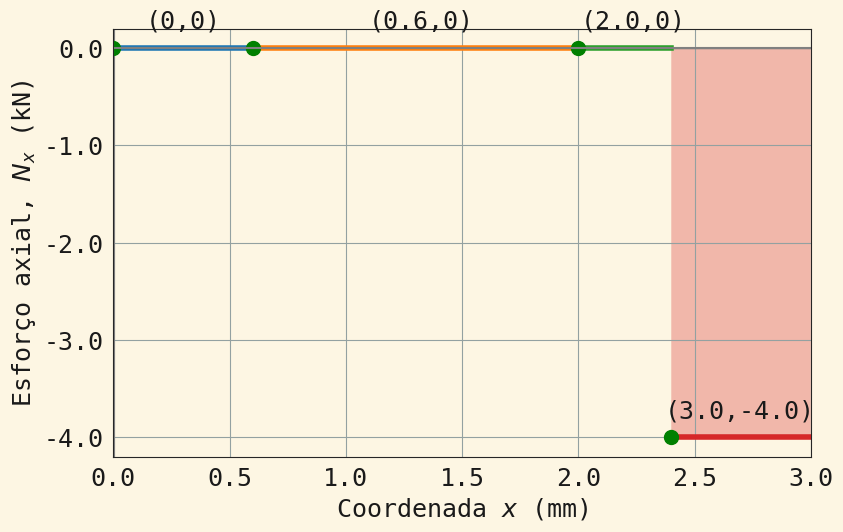

In [24]:
yymax = np.ceil(np.max([NABplot,NBCplot,NCDplot,NDEplot]))
yymin = np.floor(np.min([NABplot,NBCplot,NCDplot,NDEplot]))

fig = plt.figure(figsize=(9,5.56))
ax = fig.add_subplot(1, 1, 1)
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
# plots por troço
plt.plot(xAB,NABplot,linewidth=4)
plt.fill_between(xAB,NABplot, alpha=.3)
plt.plot(xBC,NBCplot,linewidth=4)
plt.fill_between(xBC,NBCplot, alpha=.3)
plt.plot(xCD,NCDplot,linewidth=4)
plt.fill_between(xCD,NCDplot, alpha=.3)
plt.plot(xDE,NDEplot,linewidth=4)
plt.fill_between(xDE,NDEplot, alpha=.3)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Esforço axial, $N_{x}$ (kN)')
# plots de pontos relevantes
# A
plt.plot(xAB[0],NABplot[0],'go',markersize=10)
plt.text(.14,.2,f'({xAB[0]:.0f},{NABplot[0]:.0f})',fontsize=18)
# B
plt.plot(xAB[-1],NABplot[-1],'go',markersize=10)
plt.text(xAB[-1]+.5,.2,f'({xAB[-1]:.1f},{NABplot[-1]:.0f})',fontsize=18)
# C
plt.plot(xBC[-1],NBCplot[-1],'go',markersize=10)
plt.text(xBC[-1]+.01,0.2,f'({xBC[-1]:.1f},{NBCplot[-1]:.0f})',fontsize=18)
# E
plt.plot(xDE[0],NDEplot[0],'go',markersize=10)
plt.text(xDE[-1]*.79,NDEplot[-1]*.95,f'({xDE[-1]:.1f},{NDEplot[-1]:.1f})',
         fontsize=18)

plt.axhline(y=0, color='gray', linestyle='-')
plt.axvline(x=0, color='gray', linestyle='-')
plt.xlim(0,inp.LAE)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, inp.LAE+.5, .5) # [0,2,4,6,8,10,12,14,16]
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
yrang = np.arange(yymin, yymax+1, 1) # [0,2,4,6,8,10,12,14,16]
ax.set_yticks(yrang)
ax.set_yticklabels([i for i in yrang])
plt.grid(True)
plt.show()

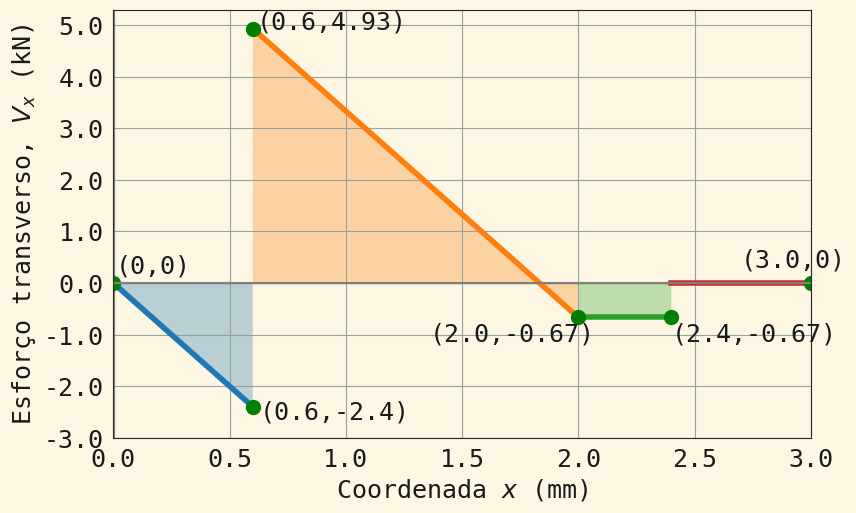

In [25]:
yymax = np.ceil(np.max([VABplot,VBCplot,VCDplot,VDEplot]))
yymin = np.floor(np.min([VABplot,VBCplot,VCDplot,VDEplot]))

fig = plt.figure(figsize=(9,5.56))
ax = fig.add_subplot(1, 1, 1)
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
# plots por troço
plt.plot(xAB,VABplot,linewidth=4)
plt.fill_between(xAB,VABplot, alpha=.3)
plt.plot(xBC,VBCplot,linewidth=4)
plt.fill_between(xBC,VBCplot, alpha=.3)
plt.plot(xCD,VCDplot,linewidth=4)
plt.fill_between(xCD,VCDplot, alpha=.3)
plt.plot(xDE,VDEplot,linewidth=4)
plt.fill_between(xDE,VDEplot, alpha=.3)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
# plots de pontos relevantes
# A
plt.plot(xAB[0],VABplot[0],'go',markersize=10)
plt.text(.01,.2,f'({xAB[0]:.0f},{VABplot[0]:.0f})',fontsize=18)
# B
plt.plot(xAB[-1],VABplot[-1],'go',markersize=10)
plt.text(xAB[-1]*1.05,VABplot[-1]*1.1,f'({xAB[-1]:.1f},{VABplot[-1]:.1f})',
         fontsize=18)
plt.plot(xBC[0],VBCplot[0],'go',markersize=10)
plt.text(xBC[0]*1.03,VBCplot[0]*1.,f'({xBC[0]:.1f},{VBCplot[0]:.2f})',
         fontsize=18)
# C
plt.plot(xBC[-1],VBCplot[-1],'go',markersize=10)
plt.text(xBC[-1]*.68,VBCplot[-1]*1.7,f'({xBC[-1]:.1f},{VBCplot[-1]:.2f})',
         fontsize=18)
# D
plt.plot(xCD[-1],VCDplot[-1],'go',markersize=10)
plt.text(xCD[-1]*1.,VCDplot[-1]*1.7,f'({xCD[-1]:.1f},{VCDplot[-1]:.2f})',
         fontsize=18)
# E
plt.plot(xDE[-1],VDEplot[-1],'go',markersize=10)
plt.text(xDE[-1]*.9,.3,f'({xDE[-1]:.1f},{VDEplot[-1]:.0f})',fontsize=18)

plt.axhline(y=0, color='gray', linestyle='-')
plt.axvline(x=0, color='gray', linestyle='-')
plt.xlim(0,inp.LAE)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, inp.LAE+.5, .5) # [0,2,4,6,8,10,12,14,16]
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
yrang = np.arange(yymin, yymax+1, 1) # [0,2,4,6,8,10,12,14,16]
ax.set_yticks(yrang)
ax.set_yticklabels([i for i in yrang])
plt.grid(True)
plt.show()

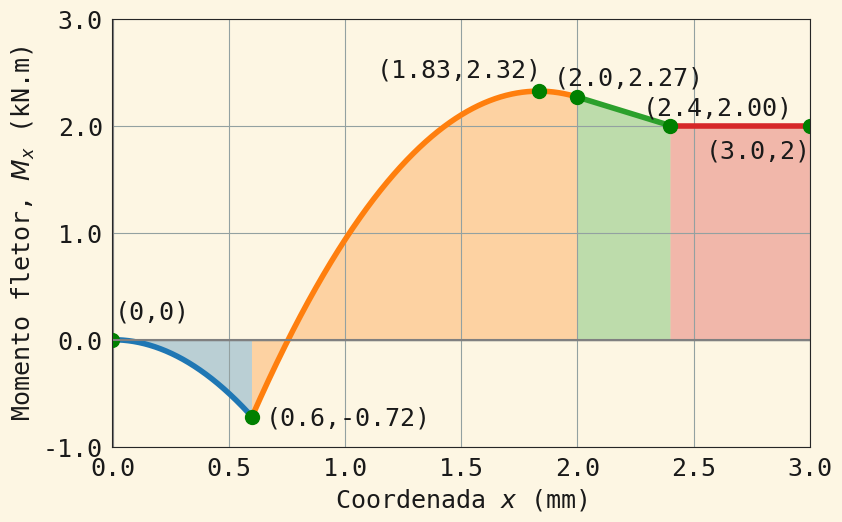

In [26]:
sol1 = solve(VBC,x)
xVBC = sol1[0]
Mmax = MBC.subs(x,xVBC)

yymax = np.ceil(np.max([MABplot,MBCplot,MCDplot,MDEplot]))
yymin = np.floor(np.min([MABplot,MBCplot,MCDplot,MDEplot]))

fig = plt.figure(figsize=(9,5.56))
ax = fig.add_subplot(1, 1, 1)
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
# plots por troço
plt.plot(xAB,MABplot,linewidth=4)
plt.fill_between(xAB,MABplot, alpha=.3)
plt.plot(xBC,MBCplot,linewidth=4)
plt.fill_between(xBC,MBCplot, alpha=.3)
plt.plot(xCD,MCDplot,linewidth=4)
plt.fill_between(xCD,MCDplot, alpha=.3)
plt.plot(xDE,MDEplot,linewidth=4)
plt.fill_between(xDE,MDEplot, alpha=.3)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Momento fletor, $M_{x}$ (kN.m)')
# plots de pontos relevantes
# A
plt.plot(xAB[0],MABplot[0],'go',markersize=10)
plt.text(.01,.2,f'({xAB[0]:.0f},{MABplot[0]:.0f})',fontsize=18)
# B
plt.plot(xBC[0],MBCplot[0],'go',markersize=10)
plt.text(xBC[0]*1.1,MBCplot[0]*1.1,f'({xBC[0]:.1f},{MBCplot[0]:.2f})',
         fontsize=18)
# max
plt.plot(xVBC,Mmax,'go',markersize=10)
plt.text(xVBC*.62,Mmax*1.06,f'({xVBC:.2f},{Mmax:.2f})',
         fontsize=18)
# C
plt.plot(xBC[-1],MBCplot[-1],'go',markersize=10)
plt.text(xBC[-1]*.95,MBCplot[-1]*1.05,f'({xBC[-1]:.1f},{MBCplot[-1]:.2f})',
         fontsize=18)
# D
plt.plot(xCD[-1],MCDplot[-1],'go',markersize=10)
plt.text(xCD[-1]*.95,MCDplot[-1]*1.05,f'({xCD[-1]:.1f},{MCDplot[-1]:.2f})',
         fontsize=18)
# E
plt.plot(xDE[-1],MDEplot[-1],'go',markersize=10)
plt.text(xDE[-1]*.85,MDEplot[-1]*.85,f'({xDE[-1]:.1f},{MDEplot[-1]:.0f})',
         fontsize=18)

plt.axhline(y=0, color='gray', linestyle='-')
plt.axvline(x=0, color='gray', linestyle='-')
plt.xlim(0,inp.LAE)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, inp.LAE+.5, .5) # [0,2,4,6,8,10,12,14,16]
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
yrang = np.arange(yymin, yymax+1, 1) # [0,2,4,6,8,10,12,14,16]
ax.set_yticks(yrang)
ax.set_yticklabels([i for i in yrang])
plt.grid(True)
plt.show()

#### d) Indique qual a secção do troço BC com o momento fletor máximo e calcule o respetivo valor. <a id="D"></a> ([_enunciatum_](#PVIII))

O momento fletor máximo na viga ocorre no troço BC da viga uma vez que é aí que o esforço transverso passa de positivo a negativo. Lembrando ainda que a relação
entre o esforço transverso e o momento fletor é:

\begin{equation*}
V(x) = \frac{\mathrm{d}M(x)}{\mathrm{d}x}
\end{equation*}

O momento fletor máximo ocorre para a condição:

\begin{equation*}
V_{BC}(x) = \frac{\mathrm{d}M_{BC}(x)}{\mathrm{d}x} = 0
\quad\Rightarrow\quad
x = 1,833~\textrm{m}
\end{equation*}

de onde resulta finalmente,

\begin{equation*}
M_{BC}(x=1,833) = 2,318~\textrm{kN.m}
\end{equation*}

In [27]:
print('--------------------------------')
print('Troço BC: Momento fletor máximo')
print('--------------------------------')
print(f'VBC(x) = 0 >>> x (in BC) = {xVBC:.3f} m ')
print('Mmax(x.V=0)  = ','{:.3f}'.format(Mmax),' kN.m')
print('max(Mplot)   = ','{:.3f}'.format(np.max(MBCplot)),' kN.m (verification)')

--------------------------------
Troço BC: Momento fletor máximo
--------------------------------
VBC(x) = 0 >>> x (in BC) = 1.833 m 
Mmax(x.V=0)  =  2.322  kN.m
max(Mplot)   =  2.322  kN.m (verification)


---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>